<a href="https://colab.research.google.com/github/PraeyOfTheGods/sephora-skincare-recommendation-week1-/blob/main/notebooks/01_data_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

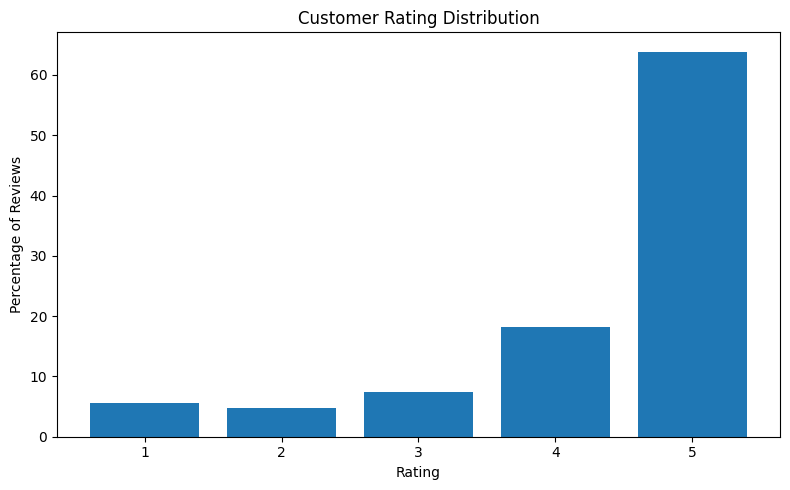

In [18]:
import matplotlib.pyplot as plt

# Rating distribution
rating_percent = (
    rating_counts / rating_counts.sum() * 100
)

plt.figure(figsize=(8, 5))
plt.bar(
    rating_percent.index.astype(str),
    rating_percent.values
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Percentage of Reviews")

plt.tight_layout()
plt.show()

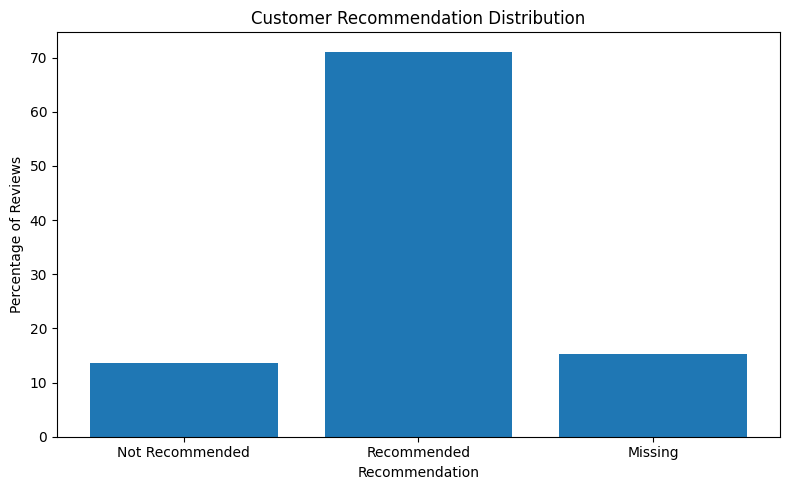

In [20]:
# Recommendation distribution

recommendation_percent = (
    recommendation_counts / recommendation_counts.sum() * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Not Recommended", "Recommended", "Missing"],
    recommendation_percent.values
)

plt.title("Customer Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Percentage of Reviews")

plt.tight_layout()
plt.show()

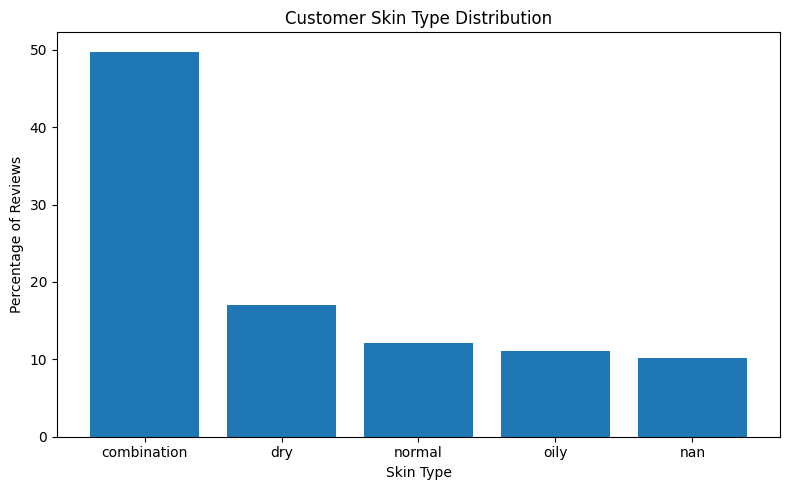

In [21]:
# Skin type distribution

skin_type_percent = (
    skin_type_counts / skin_type_counts.sum() * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    skin_type_percent.index.astype(str),
    skin_type_percent.values
)

plt.title("Customer Skin Type Distribution")
plt.xlabel("Skin Type")
plt.ylabel("Percentage of Reviews")

plt.tight_layout()
plt.show()

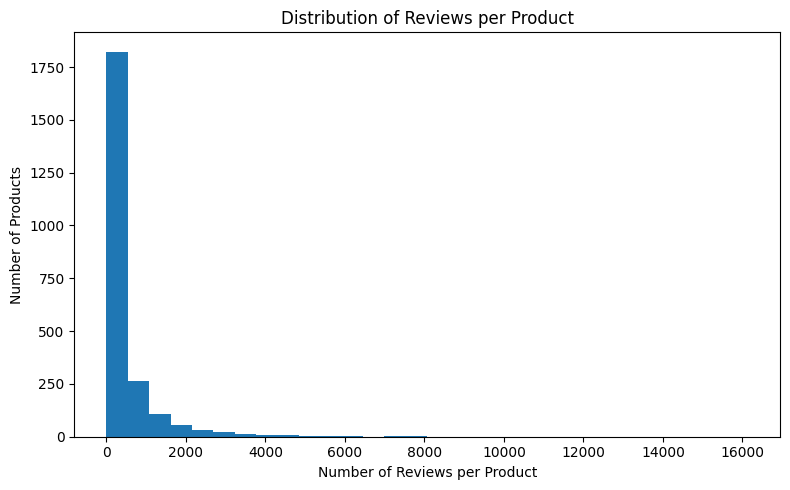

In [22]:
# Product review count distribution

plt.figure(figsize=(8, 5))

plt.hist(
    product_review_counts.values,
    bins=30
)

plt.title("Distribution of Reviews per Product")
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [23]:
# Cold-start / low-history products

low_history_products = (product_review_counts < 20).sum()
total_reviewed_products = len(product_review_counts)

low_history_percent = (
    low_history_products / total_reviewed_products * 100
)

print("Products with fewer than 20 reviews:", low_history_products)
print("Total products with reviews:", total_reviewed_products)
print(f"Percentage of low-history products: {low_history_percent:.2f}%")

Products with fewer than 20 reviews: 417
Total products with reviews: 2351
Percentage of low-history products: 17.74%


In [17]:
product_review_counts = {}

for file in review_files:
    path = f"/content/{file}"

    df = pd.read_csv(
        path,
        usecols=["product_id"],
        low_memory=False
    )

    counts = df["product_id"].dropna().astype(str).value_counts()

    for product, count in counts.items():
        product_review_counts[product] = product_review_counts.get(product, 0) + count

    del df

product_review_counts = pd.Series(product_review_counts)

print("Products with reviews:", len(product_review_counts))
print("Median reviews per product:", product_review_counts.median())

cold_start = product_review_counts < 20

print("Products with fewer than 20 reviews:", cold_start.sum())
print(
    "Percentage:",
    round(cold_start.mean() * 100, 2),
    "%"
)

Products with reviews: 2351
Median reviews per product: 164.0
Products with fewer than 20 reviews: 417
Percentage: 17.74 %


In [16]:
reviewer_counts = {}

for file in review_files:
    path = f"/content/{file}"

    df = pd.read_csv(
        path,
        usecols=["author_id"],
        low_memory=False
    )

    counts = df["author_id"].dropna().astype(str).value_counts()

    for author, count in counts.items():
        reviewer_counts[author] = reviewer_counts.get(author, 0) + count

    del df

reviewer_counts = pd.Series(reviewer_counts)

print("Total reviewers:", len(reviewer_counts))
print("Median reviews per reviewer:", reviewer_counts.median())
print(
    "Reviewers with exactly 1 review:",
    (reviewer_counts == 1).sum()
)
print(
    "Percentage with exactly 1 review:",
    round((reviewer_counts == 1).mean() * 100, 2),
    "%"
)

Total reviewers: 503216
Median reviews per reviewer: 1.0
Reviewers with exactly 1 review: 292748
Percentage with exactly 1 review: 58.18 %


In [15]:
skin_type_counts = pd.Series(dtype="int64")

for file in review_files:
    path = f"/content/{file}"

    df = pd.read_csv(
        path,
        usecols=["skin_type"],
        low_memory=False
    )

    counts = df["skin_type"].value_counts(dropna=False)
    skin_type_counts = skin_type_counts.add(counts, fill_value=0)

    del df

skin_type_counts = skin_type_counts.sort_values(ascending=False)

print("Skin type distribution:")
print(skin_type_counts)

print("\nPercentage:")
print(
    (skin_type_counts / skin_type_counts.sum() * 100)
    .round(2)
)

Skin type distribution:
combination    544513.0
dry            185937.0
normal         131910.0
oily           120494.0
NaN            111557.0
dtype: float64

Percentage:
combination    49.75
dry            16.99
normal         12.05
oily           11.01
NaN            10.19
dtype: float64


In [14]:
recommendation_counts = pd.Series(dtype="int64")

for file in review_files:
    path = f"/content/{file}"

    df = pd.read_csv(
        path,
        usecols=["is_recommended"],
        low_memory=False
    )

    counts = df["is_recommended"].value_counts(dropna=False)
    recommendation_counts = recommendation_counts.add(counts, fill_value=0)

    del df

recommendation_counts = recommendation_counts.sort_index()

print("Recommendation distribution:")
print(recommendation_counts)

print("\nPercentage:")
print(
    (recommendation_counts / recommendation_counts.sum() * 100)
    .round(2)
)

Recommendation distribution:
is_recommended
0.0    148263.0
1.0    778160.0
NaN    167988.0
dtype: float64

Percentage:
is_recommended
0.0    13.55
1.0    71.10
NaN    15.35
dtype: float64


In [13]:
rating_counts = pd.Series(dtype="int64")

for file in review_files:
    path = f"/content/{file}"

    df = pd.read_csv(
        path,
        usecols=["rating"],
        low_memory=False
    )

    counts = df["rating"].value_counts()
    rating_counts = rating_counts.add(counts, fill_value=0)

    del df

rating_counts = rating_counts.sort_index().astype(int)

print("Rating distribution:")
print(rating_counts)

print("\nPercentage:")
print((rating_counts / rating_counts.sum() * 100).round(2))

Rating distribution:
rating
1     61223
2     53032
3     81816
4    199389
5    698951
dtype: int64

Percentage:
rating
1     5.59
2     4.85
3     7.48
4    18.22
5    63.87
dtype: float64


In [12]:
review_files = [
    "reviews_0-250.csv",
    "reviews_250-500.csv",
    "reviews_500-750.csv",
    "reviews_750-1250.csv",
    "reviews_1250-end.csv"
]

all_product_ids = set()
all_author_ids = set()
total_reviews = 0

for file in review_files:
    path = f"/content/{file}"

    df = pd.read_csv(
        path,
        usecols=["product_id", "author_id"],
        low_memory=False
    )

    total_reviews += len(df)
    all_product_ids.update(df["product_id"].dropna().astype(str))
    all_author_ids.update(df["author_id"].dropna().astype(str))

    print(f"Processed {file}")

print("\n--- Review Audit ---")
print(f"Total reviews: {total_reviews:,}")
print(f"Unique products: {len(all_product_ids):,}")
print(f"Unique reviewers: {len(all_author_ids):,}")

Processed reviews_0-250.csv
Processed reviews_250-500.csv
Processed reviews_500-750.csv
Processed reviews_750-1250.csv
Processed reviews_1250-end.csv

--- Review Audit ---
Total reviews: 1,094,411
Unique products: 2,351
Unique reviewers: 503,216


In [11]:
import os
import pandas as pd

review_files = [
    "reviews_0-250.csv",
    "reviews_250-500.csv",
    "reviews_500-750.csv",
    "reviews_750-1250.csv",
    "reviews_1250-end.csv"
]

for file in review_files:
    path = f"/content/{file}"
    df = pd.read_csv(path, low_memory=False)
    print(f"{file}: {len(df):,} rows")
    del df

reviews_0-250.csv: 602,130 rows
reviews_250-500.csv: 206,725 rows
reviews_500-750.csv: 116,262 rows
reviews_750-1250.csv: 119,317 rows
reviews_1250-end.csv: 49,977 rows


In [10]:
reviews_0_250 = pd.read_csv("/content/reviews_0-250.csv")

print("Shape:", reviews_0_250.shape)
print("\nColumns:")
print(reviews_0_250.columns.tolist())

/tmp/ipykernel_3223/1445284851.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_0_250 = pd.read_csv("/content/reviews_0-250.csv")


Shape: (602130, 19)

Columns:
['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']


In [9]:
products["primary_category"].value_counts()

,count
primary_category,
Skincare,2420
Makeup,2369
Hair,1464
Fragrance,1432
Bath & Body,405
Mini Size,288
Men,60
Tools & Brushes,52
Gifts,4


In [8]:
products.isnull().sum().sort_values(ascending=False)

,0
sale_price_usd,8224
value_price_usd,8043
variation_desc,7244
child_max_price,5740
child_min_price,5740
highlights,2207
size,1631
variation_value,1598
variation_type,1444
tertiary_category,990


In [7]:
# Show the first 5 products
products.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [6]:
import pandas as pd

products = pd.read_csv("/content/product_info.csv")

print("Product dataset shape:", products.shape)
print("\nColumns:")
print(products.columns.tolist())

Product dataset shape: (8494, 27)

Columns:
['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count', 'rating', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']


In [5]:
import pandas as pd
import os

# Check that the files are available
files = os.listdir("/content")

print("Files in Colab:")
for file in files:
    if file.endswith(".csv"):
        print("-", file)

Files in Colab:
- reviews_1250-end.csv
- reviews_250-500.csv
- reviews_500-750.csv
- reviews_750-1250.csv
- product_info.csv
- reviews_0-250.csv
